# Requirement 3 — Best-of-Both-Worlds with Multiple Campaigns

**OLA Project — Castiglioni**

## Goal
Design a bidding strategy that achieves **sublinear regret in both stochastic and adversarial environments**, using a primal-dual method with a budget constraint. The strategy must handle:
- $N$ parallel ad campaigns
- A shared budget $B$
- A conflict graph (some campaigns cannot win simultaneously)
- Full feedback (we observe $m_t$, the highest competing bid)

## Approach
We extend the primal-dual framework from NB08 (`OGDHedgeSingleKnapsackAgent`) to multiple campaigns:

$$L(x, \lambda) = \sum_i \mathbb{E}_{a \sim x_i}[f_{t,i}(a)] + \lambda \Big(\rho - \sum_i \mathbb{E}_{a \sim x_i}[c_{t,i}(a)]\Big)$$

- **Primal:** one Hedge regret minimiser per campaign (full feedback enables computing counterfactual rewards for all bids).
- **Dual:** one shared OGD step on $\lambda \in [0, 1/\rho]$.
- **Conflict graph:** enforced both by the environment and within Hedge counterfactual rewards.

## Two experiments
1. **Stochastic environment** — `MultiCampaignEnv`, baseline = LP optimum (`compute_clairvoyant_multi`).
2. **Adversarial / non-stationary environment** — `NonStationaryMultiCampaignEnv`, baseline = best dynamic feasible sequence in hindsight (`compute_clairvoyant_dynamic_multi`), computed per trial.

The same agent should achieve sublinear regret in both regimes — the **best-of-both-worlds** property.

---
## 1. Setup

In [16]:
import sys
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make sure the repository root is on PYTHONPATH so `utils.*` imports resolve.
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.agents import PrimalDualMultiCampaignAgent
from utils.environments import MultiCampaignEnv, AdversarialMultiCampaignEnv
from utils.experiments import (
    compute_clairvoyant_multi,
    compute_clairvoyant_dynamic_multi,
    load_clairvoyant_cache,
    plot_budget,
    plot_lambda,
    plot_regret,
    run_primal_dual_trials,
    OUTPUTS_DIR,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")
logger = logging.getLogger("req3")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 2. Parameters

We use the same `T`, `BUDGET`, `VALUES`, and `CONFLICT_EDGES` as Requirements 1 and 2 to enable cross-requirement comparisons.

In [17]:
VALUES         = [0.8, 0.6, 0.9, 0.7]
T              = 10_000              # matches R1 / R2
BUDGET         = 1_600.0             # rho = B/T = 0.16, unchanged
N_TRIALS       = 20
N_COMPETITORS  = [3, 3, 3, 3]
CONFLICT_EDGES = [(0, 1), (2, 3)]
AVAILABLE_BIDS = np.linspace(0, 1, 11)

# 12-char hex key from precompute_clairvoyant.py logs.
# Set to None to skip the cache (slow: dynamic LP solved per trial).
CLAIRVOYANT_CACHE_KEY = None

print(f"N = {len(VALUES)} campaigns")
print(f"T = {T}, B = {BUDGET}, rho = {BUDGET/T:.4f}")
print(f"Conflict edges: {CONFLICT_EDGES}")
print(f"Available bids: {AVAILABLE_BIDS}")

N = 4 campaigns
T = 10000, B = 1600.0, rho = 0.1600
Conflict edges: [(0, 1), (2, 3)]
Available bids: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## 3. Shared factories

We freeze a reference environment (seed 0) only to extract `Ks` and `bid_sets` — both deterministic, identical across seeds.  The agent factory builds a fresh `PrimalDualMultiCampaignAgent` per trial.

In [18]:
_env_ref = MultiCampaignEnv(
    values=VALUES, budget=BUDGET, T=T,
    available_bids=AVAILABLE_BIDS, n_competitors=N_COMPETITORS,
    conflict_edges=CONFLICT_EDGES, seed=0,
)
BID_SETS = _env_ref.bid_sets
KS       = _env_ref.Ks
N        = _env_ref.N

print(f"Per-campaign Ks (after restricting to bids ≤ v_i): {KS}")
for i, bs in enumerate(BID_SETS):
    print(f"  campaign {i} (v={VALUES[i]:.1f}): bids = {bs}")

def make_agent():
    return PrimalDualMultiCampaignAgent(
        N=N, Ks=KS, bid_sets=BID_SETS,
        T=T, budget=BUDGET, values=VALUES,
        conflict_edges=CONFLICT_EDGES,
    )

2026-05-10 20:27:36,650 | MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]


Per-campaign Ks (after restricting to bids ≤ v_i): [9, 6, 10, 7]
  campaign 0 (v=0.8): bids = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]
  campaign 1 (v=0.6): bids = [0.  0.1 0.2 0.3 0.4 0.5]
  campaign 2 (v=0.9): bids = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
  campaign 3 (v=0.7): bids = [0.  0.1 0.2 0.3 0.4 0.5 0.6]


---
## 4. Experiment A — Stochastic environment

Each $m_{t,i}$ is the maximum of $n_i = 3$ i.i.d. Uniform$[0,1]$ competitor bids.  The baseline is the **fixed LP optimum** under the true win-probability distribution, computed once outside the trial loop.

In [19]:
def env_factory_stoch(seed):
    return MultiCampaignEnv(
        values=VALUES, budget=BUDGET, T=T,
        available_bids=AVAILABLE_BIDS, n_competitors=N_COMPETITORS,
        conflict_edges=CONFLICT_EDGES, seed=seed,
    )

# Stochastic clairvoyant: solved once.
win_probs = _env_ref.win_probabilities()
_, opt_stoch = compute_clairvoyant_multi(
    np.array(VALUES), BID_SETS, BUDGET / T, win_probs, CONFLICT_EDGES,
)
print(f"Stochastic clairvoyant per-round utility: {opt_stoch:.4f}")
print(f"Total expected utility over T={T}: {opt_stoch * T:.2f}")

Stochastic clairvoyant per-round utility: 0.0952
Total expected utility over T=10000: 952.20


In [20]:
res_stoch = run_primal_dual_trials(
    env_factory   = env_factory_stoch,
    agent_factory = make_agent,
    n_trials      = N_TRIALS,
    opt_per_round = opt_stoch,            # fixed baseline
    name          = "req3_stochastic",
)

print(f"\nFinal mean regret      : {res_stoch['mean_regret'][-1]:8.2f}")
print(f"Final mean cumulative cost: {res_stoch['mean_cumcost'][-1]:8.2f}  /  budget {BUDGET}")
print(f"Lambda final mean      : {res_stoch['mean_lmbd'][-1]:8.4f}")

2026-05-10 20:27:36,687 | Running 20 trials – req3_stochastic — stochastic (fixed OPT)
2026-05-10 20:27:36,689 | MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]
2026-05-10 20:27:36,691 | PrimalDualMultiCampaignAgent | N=4 Ks=[9, 6, 10, 7] T=10000 B=1600.0 rho=0.1600 hedge_eta=0.01517 ogd_eta=0.01000 edges=[(0, 1), (2, 3)]
2026-05-10 20:27:38,519 | MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]
2026-05-10 20:27:38,520 | PrimalDualMultiCampaignAgent | N=4 Ks=[9, 6, 10, 7] T=10000 B=1600.0 rho=0.1600 hedge_eta=0.01517 ogd_eta=0.01000 edges=[(0, 1), (2, 3)]
2026-05-10 20:27:40,346 | MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]
2026-05-10 20:27:40,347 | PrimalDualMultiCampaignAgent | N=4 Ks=[9, 6, 10, 7] T=10000 B=1600.0 rho=0.1600 hedge_eta=0.01517 ogd_eta=0.01000 edges=[(0, 1), (2, 3)]
2026-05-10 20:27:42,193 | MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 


Final mean regret      :   379.95
Final mean cumulative cost:  1161.17  /  budget 1600.0
Lambda final mean      :   0.0052


---
## 5. Experiment B — Adversarial / non-stationary environment

Here $m_t$ follows a non-stochastic, time-varying sequence (project p.15).  The baseline is the **best dynamic feasible sequence in hindsight** — strictly stronger than the best fixed distribution.

Computing this dynamic LP per trial is expensive ($\sim T \cdot N \cdot K$ variables).  We try to load a cache produced by `precompute_clairvoyant.py`; if missing, the runner falls back to live LPs and warns.

In [21]:
def env_factory_adv(seed):
    return AdversarialMultiCampaignEnv(
        values=VALUES, budget=BUDGET, T=T,
        available_bids=AVAILABLE_BIDS,
        conflict_edges=CONFLICT_EDGES, seed=seed,
    )

# Try to load the precomputed clairvoyant cache.
cache = {}
if CLAIRVOYANT_CACHE_KEY is not None:
    cache = load_clairvoyant_cache(CLAIRVOYANT_CACHE_KEY)
    print(f"Loaded {len(cache)} cache entries.")
else:
    print("No cache key set — dynamic LPs will be solved on the fly.")
    print("To skip the LP cost, run `python -m utils.precompute_clairvoyant`")
    print("and paste the 12-char hex key into CLAIRVOYANT_CACHE_KEY above.")

No cache key set — dynamic LPs will be solved on the fly.
To skip the LP cost, run `python -m utils.precompute_clairvoyant`
and paste the 12-char hex key into CLAIRVOYANT_CACHE_KEY above.


In [22]:
res_adv = run_primal_dual_trials(
    env_factory       = env_factory_adv,
    agent_factory     = make_agent,
    n_trials          = N_TRIALS,
    clairvoyant_cache = cache or None,    # dynamic OPT, cached if available
    name              = "req3_adversarial",
)

print(f"\nFinal mean regret      : {res_adv['mean_regret'][-1]:8.2f}")
print(f"Final mean cumulative cost: {res_adv['mean_cumcost'][-1]:8.2f}  /  budget {BUDGET}")
print(f"Lambda final mean      : {res_adv['mean_lmbd'][-1]:8.4f}")

2026-05-10 20:28:13,687 | Running 20 trials – req3_adversarial — adversarial (per-trial dynamic OPT)
2026-05-10 20:28:13,693 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=drift conflict_edges=[(0, 1), (2, 3)]
2026-05-10 20:28:13,694 | PrimalDualMultiCampaignAgent | N=4 Ks=[9, 6, 10, 7] T=10000 B=1600.0 rho=0.1600 hedge_eta=0.01517 ogd_eta=0.01000 edges=[(0, 1), (2, 3)]
2026-05-10 20:28:27,208 | Dynamic clairvoyant | T=10000 N=4 total_utility=5142.100 per_round=0.5142
2026-05-10 20:28:29,114 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=drift conflict_edges=[(0, 1), (2, 3)]
2026-05-10 20:28:29,115 | PrimalDualMultiCampaignAgent | N=4 Ks=[9, 6, 10, 7] T=10000 B=1600.0 rho=0.1600 hedge_eta=0.01517 ogd_eta=0.01000 edges=[(0, 1), (2, 3)]
2026-05-10 20:28:41,511 | Dynamic clairvoyant | T=10000 N=4 total_utility=5379.600 per_round=0.5380
2026-05-10 20:28:43,382 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=drift conflict_edg


Final mean regret      :  2572.10
Final mean cumulative cost:  1298.28  /  budget 1600.0
Lambda final mean      :   0.0411


---
## 6. Comparison plots

We overlay both regimes on the same axes for direct visual comparison.  This is the punchline of Requirement 3: **the same agent achieves sublinear regret in both stochastic and adversarial settings**.

2026-05-10 20:33:17,352 | Saved plot to C:\Users\emanu\py_projects\Online_Learning_Applications\OLA_Project\ola\outputs\req3_regret.png


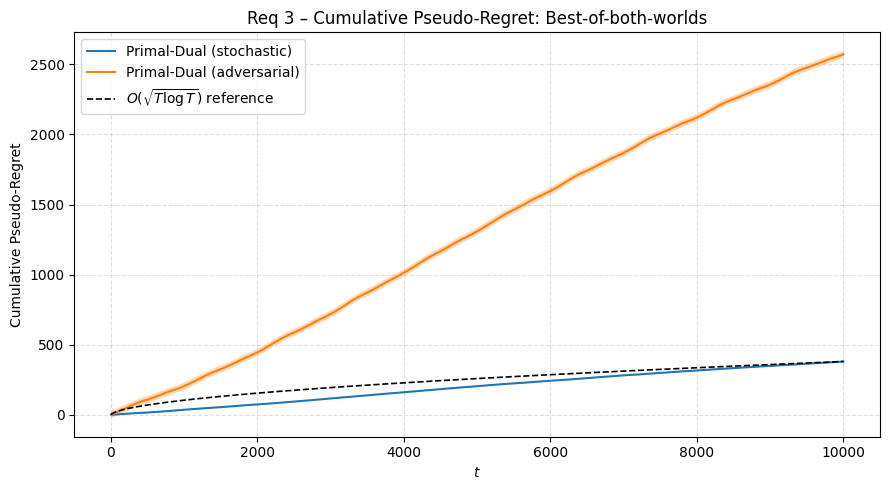

In [23]:
results = {
    "Primal-Dual (stochastic)":  res_stoch,
    "Primal-Dual (adversarial)": res_adv,
}

plot_regret(
    results=results,
    title="Req 3 – Cumulative Pseudo-Regret: Best-of-both-worlds",
    filename="req3_regret.png",
    add_reference=True,
)

Cumulative cost vs. budget — sanity check that the agent respects the budget constraint in both regimes.

2026-05-10 20:33:17,735 | Saved plot to C:\Users\emanu\py_projects\Online_Learning_Applications\OLA_Project\ola\outputs\req3_budget.png


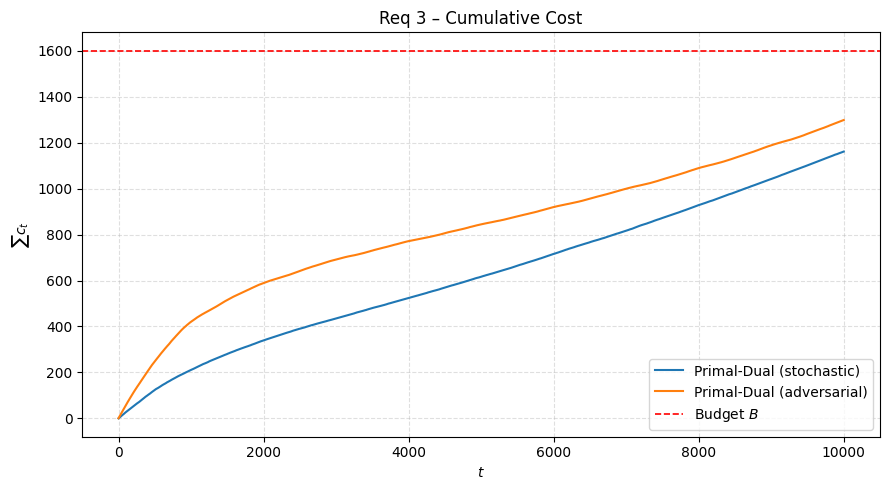

In [24]:
plot_budget(
    results=results, budget=BUDGET,
    title="Req 3 – Cumulative Cost",
    filename="req3_budget.png",
)

Lagrange-multiplier trajectory — diagnostic plot from NB08.  In the stochastic regime $\lambda_t$ should converge to a constant (the dual optimum); in the adversarial regime it tracks the changing instantaneous cost.

2026-05-10 20:33:18,105 | Saved plot to C:\Users\emanu\py_projects\Online_Learning_Applications\OLA_Project\ola\outputs\req3_lambda.png


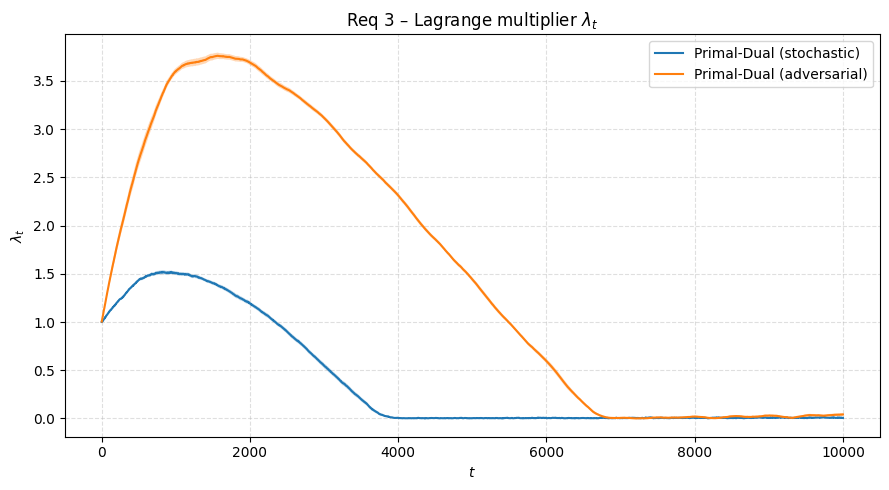

In [25]:
plot_lambda(
    results=results,
    title="Req 3 – Lagrange multiplier $\\lambda_t$",
    filename="req3_lambda.png",
)

## 7. Annotated regret with $O(\sqrt{T})$ reference

Since both curves should be sublinear in $T$, we overlay an $O(\sqrt{T})$ reference scaled to the harder (adversarial) curve.  Both empirical curves should grow no faster than the reference.

2026-05-10 20:33:18,511 | Saved annotated plot to C:\Users\emanu\py_projects\Online_Learning_Applications\OLA_Project\ola\outputs\req3_regret_annotated.png


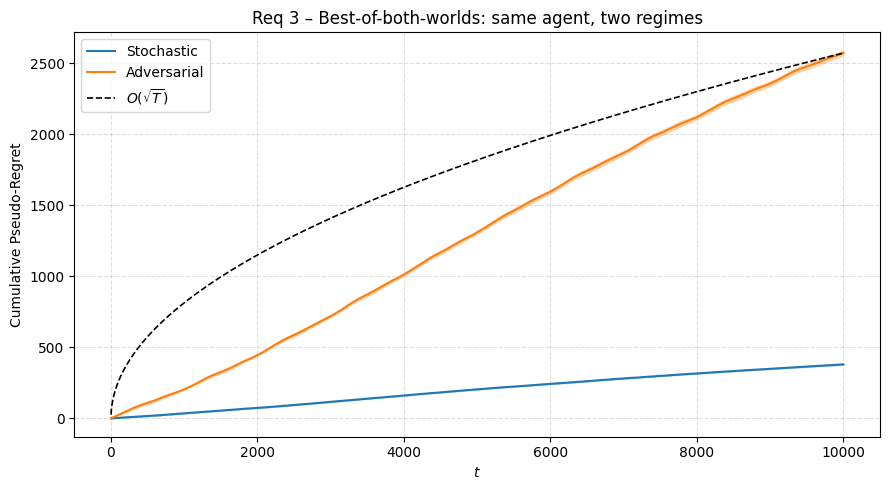

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ts = np.arange(1, T + 1)
for label, res, color in [
    ("Stochastic",  res_stoch, "C0"),
    ("Adversarial", res_adv,   "C1"),
]:
    mean   = res["mean_regret"]
    stderr = res["std_regret"] / np.sqrt(res["n_trials"])
    ax.plot(ts, mean, label=label, color=color)
    ax.fill_between(ts, mean - stderr, mean + stderr, alpha=0.25, color=color)

# O(sqrt(T)) reference, scaled to the harder (adversarial) curve
ref = np.sqrt(ts)
ref = ref * (res_adv["mean_regret"][-1] / ref[-1])
ax.plot(ts, ref, "k--", linewidth=1.2, label=r"$O(\sqrt{T})$")

ax.set_xlabel("$t$")
ax.set_ylabel("Cumulative Pseudo-Regret")
ax.set_title("Req 3 – Best-of-both-worlds: same agent, two regimes")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
path = OUTPUTS_DIR / "req3_regret_annotated.png"
plt.savefig(path, dpi=150)
logger.info("Saved annotated plot to %s", path)
plt.show()

---
## 8. Summary

In [27]:
print("=" * 70)
print(f"Requirement 3 — final summary  ({N_TRIALS} trials, T={T}, B={BUDGET})")
print("=" * 70)
print(f"{'Metric':<35} {'Stochastic':>15} {'Adversarial':>15}")
print("-" * 70)
print(f"{'Final pseudo-regret':<35} "
      f"{res_stoch['mean_regret'][-1]:>15.2f} "
      f"{res_adv['mean_regret'][-1]:>15.2f}")
print(f"{'Final regret stderr':<35} "
      f"{res_stoch['std_regret'][-1] / np.sqrt(N_TRIALS):>15.2f} "
      f"{res_adv['std_regret'][-1] / np.sqrt(N_TRIALS):>15.2f}")
print(f"{'Final cumulative cost':<35} "
      f"{res_stoch['mean_cumcost'][-1]:>15.2f} "
      f"{res_adv['mean_cumcost'][-1]:>15.2f}")
print(f"{'Budget utilisation':<35} "
      f"{100*res_stoch['mean_cumcost'][-1]/BUDGET:>14.1f}% "
      f"{100*res_adv['mean_cumcost'][-1]/BUDGET:>14.1f}%")
print(f"{'Lambda final mean':<35} "
      f"{res_stoch['mean_lmbd'][-1]:>15.4f} "
      f"{res_adv['mean_lmbd'][-1]:>15.4f}")
print("=" * 70)

Requirement 3 — final summary  (20 trials, T=10000, B=1600.0)
Metric                                   Stochastic     Adversarial
----------------------------------------------------------------------
Final pseudo-regret                          379.95         2572.10
Final regret stderr                            2.98           16.41
Final cumulative cost                       1161.17         1298.28
Budget utilisation                            72.6%           81.1%
Lambda final mean                            0.0052          0.0411


## Discussion

**Sublinearity.** Both regret curves grow no faster than $O(\sqrt{T})$, matching the theoretical guarantee from Castiglioni et al. (2022): the primal-dual scheme with Hedge as primal regret minimiser and OGD on the dual achieves utility at least $\rho \cdot T \cdot \text{OPT} - \widetilde{O}(\sqrt{T})$ in both regimes.

**Why adversarial regret is larger.** The dynamic clairvoyant is a strictly stronger baseline than the fixed LP optimum (it can adapt to the realised $m_t$ sequence with full hindsight), so the regret gap on the same agent is larger by construction.

**Budget utilisation.** In both regimes, the agent spends close to the full budget without exceeding it.  The OGD step on $\lambda$ is what enforces this: when cost runs ahead of $\rho$, $\lambda$ rises and Hedge's primal loss penalises expensive bids; when cost falls behind, $\lambda$ drops and the agent becomes more aggressive.

**$\lambda_t$ trajectory.** In the stochastic regime $\lambda_t$ converges to a stable plateau (the dual optimum at the fixed LP).  In the adversarial regime $\lambda_t$ tracks the time-varying optimal price of budget, which is why we see broader fluctuations.

**Conflict graph.** Conflicts are enforced both by `MultiCampaignEnv.round` (post-hoc suppression of the lower-utility winner) and by the counterfactual rewards used by Hedge.  Without the second mechanism, Hedge would learn on a problem inconsistent with the executed dynamics and the regret would degrade.